<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# <font color=18453B>CMSE 801 - Day 14</font>
## Evaluating model fits
### Feb 16, 2026

## General Course Announcements

* Quiz 2 will take place **today 8:30 am - 9 am**
* The **Project Proposal** is due by 5 pm Wednesday, March 11, **before the Day 16 class period**. Information about this is on the website and in the Day 16 PCA.


## Questions/comments from Day 14 PCA

* Commonly: the hardest part was coming up with an algorithm for determining the "goodness of fit"
* Some questions about/issues with using curve_fit -- **we can briefly look at an example**.

### When thinking about "quantifying" how well our model fits our data, it can be useful to think about "residuals"

<img src="https://i.ibb.co/BtZQnh0/Screen-Shot-2023-03-15-at-9-42-14-AM.png" border="0" width=500 align="center">

I can try to calculate the residual for each data point when compared to my model and then combine the residuals in some way to determine how "good" my fit is _quantitatively_.

### Let's try a model of the following form:

### $$ F(x) =  a e^{-bx} + c $$

In [12]:
# Let's get all of our importants out of the way first!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [13]:
# We need to define our function
# The independent variable _must be first_ and then the model parameter
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

### Let's generate a bit of data we can try to fit our model to

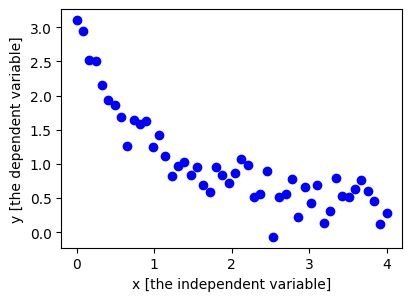

In [14]:
# Generate x values, calculate corresponding y values
xdata = np.linspace(0, 4, 50)
y = exp_func(xdata, 2.5, 1.3, 0.5)

# Add noise to the y values
y_noise = 0.2 * np.random.normal(size=xdata.size)
ydata = y + y_noise

# Plots the results
plt.figure(figsize=(4.4,3.1))
plt.scatter(xdata, ydata, color='b', label='data')
plt.xlabel("x [the independent variable]")
plt.ylabel("y [the dependent variable]");

### Ok, now we have a model and some data, let's use `curve_fit`

Best fit parameters: [2.50335451 1.30264339 0.51288316]


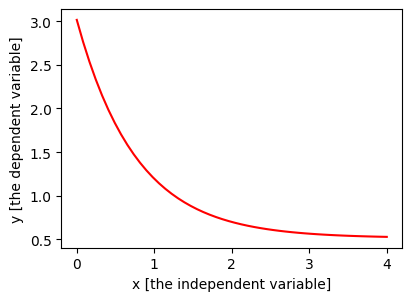

In [9]:
popt, pcov = curve_fit(exp_func, xdata, ydata)
print("Best fit parameters:",popt)

# Plot the data using our function, the x values, and our best fit to calculate y values
plt.figure(figsize=(4.4,3.1))
plt.plot(xdata, exp_func(xdata, popt[0], popt[1], popt[2]), color='r',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % (popt[0], popt[1], popt[2]))
plt.xlabel("x [the independent variable]")
plt.ylabel("y [the dependent variable]");

Best fit parameters: [2.50335451 1.30264339 0.51288316]


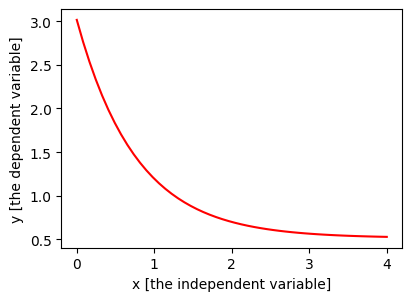

In [10]:
## I could have been more explicit about what I was doing with the best fit parameters
popt, pcov = curve_fit(exp_func, xdata, ydata)
print("Best fit parameters:",popt)
a_fit = popt[0]
b_fit = popt[1]
c_fit = popt[2]
plt.figure(figsize=(4.4,3.1))
plt.plot(xdata, exp_func(xdata, a_fit, b_fit, c_fit), color='r',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % (a_fit, b_fit, c_fit))
plt.xlabel("x [the independent variable]")
plt.ylabel("y [the dependent variable]");

### How does our model look compared to the data?

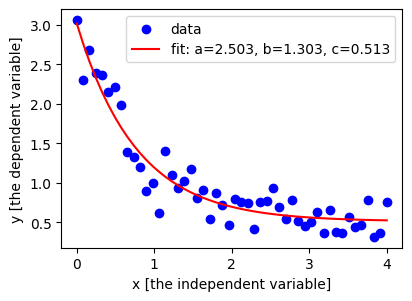

In [11]:
plt.figure(figsize=(4.4,3.1))
plt.scatter(xdata, ydata, color='b', label='data')
plt.xlabel("x [the independent variable]")
plt.ylabel("y [the dependent variable]")
plt.plot(xdata, exp_func(xdata, popt[0], popt[1], popt[2]), color='r',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % (popt[0], popt[1], popt[2]))
plt.legend();

## Goals for today
* Design an algorithm for calculating the "goodness of fit" quantitively.
* Fit multiple models to data
* Check each model and determine which one provides the best fit.

## Looking forward - Day 15 PCA: "Linear Regression" and fitting models to data

* You'll explore the concept of linear regression and how we can fit lines to look for trends in data
    * You'll be unpacking a bit about how a tool like `curve_fit` works under the hood.
* You'll also experiment more with using `curve_fit` to fit a specific model to data.